In [1]:
import os
import glob
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.sparse as sp
import time
# import gget
import anndata as an
import scanpy as sc
import scanpy.external as sce
import h5py
import scipy
from scipy.stats import pearsonr
from scipy.stats import t
from scipy.stats import mannwhitneyu
from scipy.spatial.distance import cdist
from statsmodels.stats.multitest import multipletests
from tqdm import tqdm
import matplotlib.patches as patches
import matplotlib.ticker as mticker
from matplotlib.ticker import MaxNLocator, FuncFormatter


from scipy.spatial.distance import pdist, squareform
from collections import defaultdict

sc.settings.verbosity = 2

In [3]:
print(scipy.__version__)
print(sc.__version__)

1.16.1
1.11.4


In [3]:
path = "/home/jrcwycy/HSC/Flow_Data.csv"

df = pd.read_csv(path)

df['CD34+ %'] = df['CD34+ %'].str.rstrip('%').astype(float)

print(df.shape)
df

(16, 6)


,Exp_file,Condition,N TF,CD34+ %,Recipe,Dose
0,F2HS8,Control (no lenti Dox-),NaN,0.07,NaN,NaN
1,F2HS8,Control (Dox-),5TF,0.12,FH4a,NaN
2,C1 FH6 Inactive.fcs,Control (Dox-),5TF,0.45,FH6,NaN
3,B6 FH3 Inactive.fcs,Control (Dox-),3TF,0.44,FH3,NaN
4,F2HS8,FH4a,5TF,3.08,FH4a,lo
5,F2HS8,FH4a,5TF,2.41,FH4a,lo
6,F2HS8,FH4a,5TF,2.59,FH4a,hi
7,F2HS8,FH4a,5TF,1.86,FH4a,hi
8,C3 FH6 lo.fcs,FH6,5TF,3.97,FH6,lo
9,C2 FH6.fcs,FH6,5TF,1.71,FH6,hi


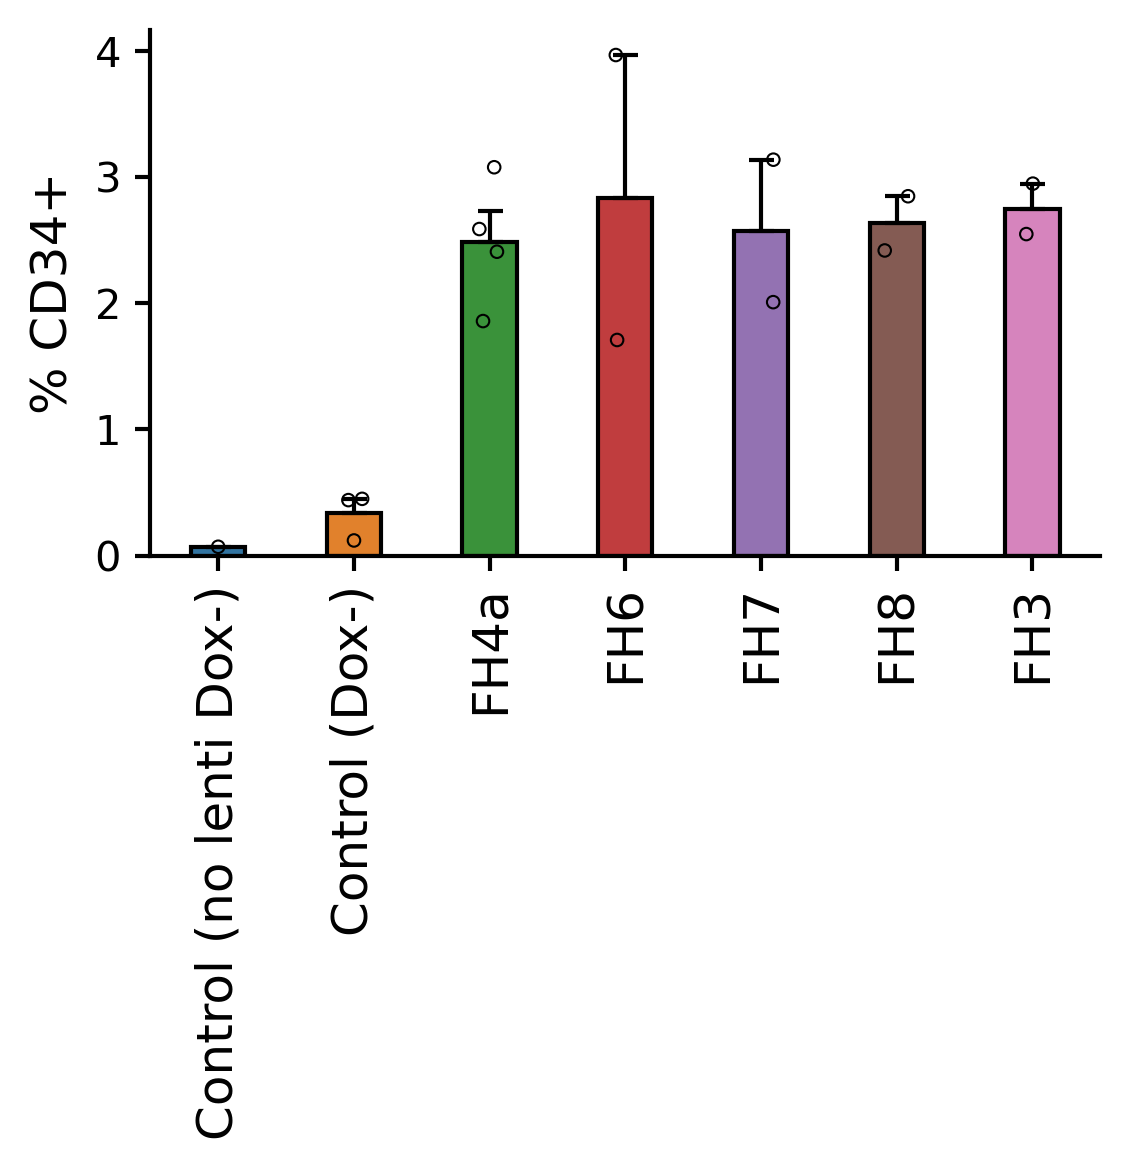

In [4]:
plt.rcParams['figure.dpi'] = 300
plt.rcParams['figure.figsize'] = 4, 4
fig, ax = plt.subplots()

order = df['Condition'].unique()
line_width = 1

sns.barplot(
    data=df,
    x='Condition',
    y='CD34+ %',
    hue='Condition',
    errorbar=None,
    capsize=0.2,
    width=0.4,
    ec='k',
    linewidth=1,
    # palette=palette,
    ax=ax,
)

# add errorbars
stats = df.groupby('Condition')['CD34+ %'].agg(['mean', 'sem']).reindex(order)
ax.errorbar(
    x=np.arange(len(order)),
    y=stats['mean'],
    yerr=[np.zeros(len(order)), stats['sem']],
    fmt='none',
    color='k',
    elinewidth=1,
    capsize=3, # 4
    zorder=10,
)

sns.stripplot(
    data=df,
    x='Condition',
    y='CD34+ %',
    marker='o',
    # dodge=True,
    jitter=0.1,
    size=3,
    edgecolor='k',
    linewidth=0.5,
    facecolors='none',
    ax=ax,
)

ax.set_ylabel("% CD34+", fontsize=12) 
ax.set_xlabel("")

# ax.axhline(y=0, ls='-', lw=1, color='k', zorder=0)

# ax.set_ylim([-2, 18])
# ax.set_yticks([0, 5, 10, 15])
# ax.margins(y=0.075)
# ax.yaxis.set_major_locator(
#     mticker.MaxNLocator(nbins=4, integer=True)
# )

# ax.margins(x=0.3)
ax.tick_params(axis='x', rotation=90, labelsize=12)
ax.tick_params(axis='y', labelsize=10)
ax.tick_params(axis='both', width=line_width)
for spine in ax.spines.values():
    spine.set_linewidth(line_width)
    
sns.despine()
plt.tight_layout() 
plt.show()     

In [5]:
df

,Exp_file,Condition,N TF,CD34+ %,Recipe,Dose
0,F2HS8,Control (no lenti Dox-),NaN,0.07,NaN,NaN
1,F2HS8,Control (Dox-),5TF,0.12,FH4a,NaN
2,C1 FH6 Inactive.fcs,Control (Dox-),5TF,0.45,FH6,NaN
3,B6 FH3 Inactive.fcs,Control (Dox-),3TF,0.44,FH3,NaN
4,F2HS8,FH4a,5TF,3.08,FH4a,lo
5,F2HS8,FH4a,5TF,2.41,FH4a,lo
6,F2HS8,FH4a,5TF,2.59,FH4a,hi
7,F2HS8,FH4a,5TF,1.86,FH4a,hi
8,C3 FH6 lo.fcs,FH6,5TF,3.97,FH6,lo
9,C2 FH6.fcs,FH6,5TF,1.71,FH6,hi


In [31]:
to_keep = ['Control (Dox-)', 'FH4a', 'FH6']

tmp = df[df['Condition'].isin(to_keep)].copy()


tmp['name'] = np.where(
    tmp['Condition'] == 'Control (Dox-)',
    'control',
    tmp['N TF']
)

tmp = tmp[tmp['N TF'] != '3TF']

tmp

,Exp_file,Condition,N TF,CD34+ %,Recipe,Dose,name
1,F2HS8,Control (Dox-),5TF,0.12,FH4a,NaN,control
2,C1 FH6 Inactive.fcs,Control (Dox-),5TF,0.45,FH6,NaN,control
4,F2HS8,FH4a,5TF,3.08,FH4a,lo,5TF
5,F2HS8,FH4a,5TF,2.41,FH4a,lo,5TF
6,F2HS8,FH4a,5TF,2.59,FH4a,hi,5TF
7,F2HS8,FH4a,5TF,1.86,FH4a,hi,5TF
8,C3 FH6 lo.fcs,FH6,5TF,3.97,FH6,lo,5TF
9,C2 FH6.fcs,FH6,5TF,1.71,FH6,hi,5TF


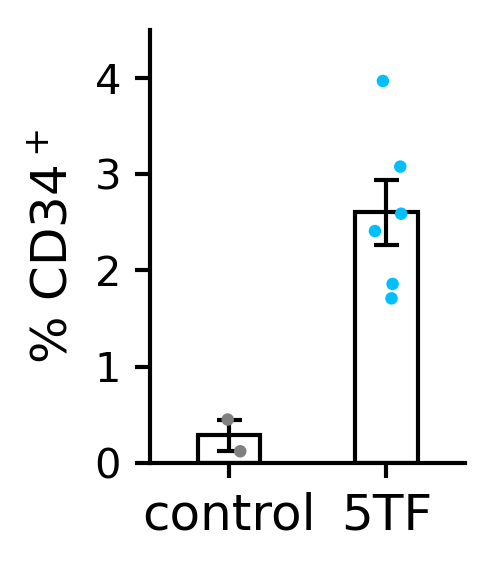

In [35]:
plt.rcParams['figure.dpi'] = 300
plt.rcParams['figure.figsize'] = 1.75, 2
fig, ax = plt.subplots()

order = ['control', '5TF']

line_width = 1

sns.barplot(
    data=tmp,
    x='name',
    y='CD34+ %',
    # hue='name',
    errorbar=None,
    capsize=0.2,
    width=0.4,
    ec='k',
    linewidth=1,
    color='white',
    # palette='dark:white',
    ax=ax,
)

# add errorbars
stats = tmp.groupby('name')['CD34+ %'].agg(['mean', 'sem']).reindex(order)
ax.errorbar(
    x=np.arange(len(order)),
    y=stats['mean'],
    yerr=stats['sem'],#[np.zeros(len(order)), stats['sem']],
    fmt='none',
    color='k',
    elinewidth=1,
    capsize=3, # 4
    zorder=1,
)

sns.stripplot(
    data=tmp,
    x='name',
    y='CD34+ %',
    hue='name',
    marker='o',
    jitter=True,
    size=3,
    edgecolor='k',
    linewidth=0,
    palette=['Grey', 'deepskyblue'],
    # facecolors='none',
    ax=ax,
)

ax.set_ylim([0, 4.5])
ax.set_ylabel("% CD34$^+$", fontsize=12) 
ax.set_xlabel("")

# ax.margins(x=0.3)
ax.tick_params(axis='x', labelsize=12)
ax.tick_params(axis='y', labelsize=10)
ax.tick_params(axis='both', width=line_width)
for spine in ax.spines.values():
    spine.set_linewidth(line_width)
    
sns.despine()
plt.tight_layout() 
plt.show()     

In [28]:
# from scipy.stats import mannwhitneyu

control = tmp.loc[tmp['name'] == 'Control', 'CD34+ %']
tf5 = tmp.loc[tmp['name'] == '5TF', 'CD34+ %']

stat, p = mannwhitneyu(control, tf5, alternative='less')
print("U =", stat, "p-value =", p)

U = 0.0 p-value = 0.03571428571428571
